# 🔍 CLIP Image Search — Retrieval Only

Notebook ini **hanya** untuk pencarian gambar menggunakan Qdrant yang sudah berisi data.
Tidak ada proses ingest/indexing di sini.

**Stack:**
- **CLIP (OpenAI)** — ekstraksi embedding dari teks/gambar query
- **Qdrant** — vector database yang sudah terisi data gambar

## 1. Install Dependencies

In [11]:
%pip install qdrant-client transformers torch Pillow matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Libraries

In [12]:
import torch
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from transformers import CLIPProcessor, CLIPModel
from qdrant_client import QdrantClient
from qdrant_client.models import Filter, FieldCondition, MatchValue

print("✅ Libraries loaded")
print(f"🔧 Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

✅ Libraries loaded
🔧 Device: cuda


## 3. Konfigurasi

In [ ]:
# ── Qdrant Config ──────────────────────────────────────
QDRANT_URL      = "http://76.13.195.1:6333"
COLLECTION_NAME = "Image_Clip_retriever"   

# ── CLIP Config ────────────────────────────────────────
CLIP_MODEL_NAME = "openai/clip-vit-large-patch14"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"🌐 Qdrant      : {QDRANT_URL}")
print(f"📦 Koleksi     : {COLLECTION_NAME}")
print(f"🤖 CLIP Model  : {CLIP_MODEL_NAME}")
print(f"🔧 Device      : {DEVICE}")

🌐 Qdrant      : http://76.13.195.1:6333
📦 Koleksi     : Image_Clip_retriever
🤖 CLIP Model  : openai/clip-vit-large-patch14
🔧 Device      : cuda


## 4. Load CLIP Model

In [14]:
print("⏳ Loading CLIP model...")
clip_model     = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model.eval()
print(f"✅ CLIP model '{CLIP_MODEL_NAME}' loaded")

⏳ Loading CLIP model...
✅ CLIP model 'openai/clip-vit-large-patch14' loaded


## 5. Koneksi ke Qdrant

In [15]:
client = QdrantClient(url=QDRANT_URL, timeout=30)

# Cek koneksi & info koleksi
info     = client.get_collections()
existing = [c.name for c in info.collections]
print(f"✅ Terhubung ke Qdrant: {QDRANT_URL}")
print(f"📋 Koleksi tersedia   : {existing}")

assert COLLECTION_NAME in existing, f"❌ Koleksi '{COLLECTION_NAME}' tidak ditemukan! Jalankan dulu notebook ingest."

col_info = client.get_collection(COLLECTION_NAME)
print(f"\n📊 Info koleksi '{COLLECTION_NAME}':")
print(f"   • Jumlah vektor : {col_info.points_count}")
print(f"   • Status        : {col_info.status}")

✅ Terhubung ke Qdrant: http://76.13.195.1:6333
📋 Koleksi tersedia   : ['semantic_chunks', 'embed_pdf_chunks_v1', 'Image_Clip_retriever']

📊 Info koleksi 'Image_Clip_retriever':
   • Jumlah vektor : 4257
   • Status        : green


## 6. Helper Functions

In [16]:
def embed_text(text: str) -> list:
    """Ekstrak embedding dari query teks menggunakan CLIP."""
    inputs = clip_processor(text=[text], return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        features = clip_model.get_text_features(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )
    features = features / features.norm(dim=-1, keepdim=True)
    return features.cpu().numpy()[0].tolist()


def embed_image(image: Image.Image) -> list:
    """Ekstrak embedding dari gambar PIL menggunakan CLIP."""
    inputs = clip_processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        features = clip_model.get_image_features(
            pixel_values=inputs["pixel_values"]
        )
    features = features / features.norm(dim=-1, keepdim=True)
    return features.cpu().numpy()[0].tolist()


def load_image_safe(path: Path) -> Image.Image | None:
    """Load gambar dengan aman, konversi ke RGB."""
    try:
        return Image.open(path).convert("RGB")
    except Exception as e:
        print(f"⚠️  Gagal load {path}: {e}")
        return None


print("✅ Helper functions defined")

✅ Helper functions defined


## 7. Fungsi Retrieval

In [17]:
def _build_filter(asset_type: str | None, source: str | None) -> Filter | None:
    """Buat filter Qdrant berdasarkan asset_type dan/atau source."""
    conditions = []
    if asset_type:
        conditions.append(FieldCondition(key="asset_type", match=MatchValue(value=asset_type)))
    if source:
        conditions.append(FieldCondition(key="source", match=MatchValue(value=source)))
    return Filter(must=conditions) if conditions else None


def search_by_text(
    query: str,
    top_k: int = 5,
    asset_type: str = None,
    source: str = None
) -> list:
    """
    Cari gambar berdasarkan query TEKS.

    Args:
        query      : String teks pencarian
        top_k      : Jumlah hasil yang dikembalikan
        asset_type : Filter 'picture' atau 'table' (opsional)
        source     : Filter berdasarkan sumber buku, misal 'Islam_BS_KLS_XII_' (opsional)
    """
    query_vector = embed_text(query)
    results = client.search(
        collection_name=COLLECTION_NAME,
        query_vector=query_vector,
        limit=top_k,
        query_filter=_build_filter(asset_type, source),
        with_payload=True
    )
    return results


def search_by_image(
    image_path: str | Path,
    top_k: int = 5,
    asset_type: str = None,
    source: str = None
) -> list:
    """
    Cari gambar berdasarkan query GAMBAR.

    Args:
        image_path : Path ke file gambar query
        top_k      : Jumlah hasil yang dikembalikan
        asset_type : Filter 'picture' atau 'table' (opsional)
        source     : Filter berdasarkan sumber buku (opsional)
    """
    img = load_image_safe(Path(image_path))
    if img is None:
        raise ValueError(f"Tidak bisa load gambar: {image_path}")

    query_vector = embed_image(img)
    results = client.search(
        collection_name=COLLECTION_NAME,
        query_vector=query_vector,
        limit=top_k,
        query_filter=_build_filter(asset_type, source),
        with_payload=True
    )
    return results


def display_results(results: list, query_label: str = "Query", cols: int = 3):
    """Tampilkan hasil pencarian dalam grid gambar."""
    n = len(results)
    if n == 0:
        print("❌ Tidak ada hasil ditemukan.")
        return

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    fig.suptitle(f'🔍 Hasil Pencarian: "{query_label}"', fontsize=14, fontweight="bold")

    axes = np.array(axes).flatten() if n > 1 else [axes]

    for i, hit in enumerate(results):
        payload  = hit.payload
        filepath = payload.get("filepath", "")
        filename = payload.get("filename", "unknown")
        score    = hit.score
        page     = payload.get("page_num", "?")
        atype    = payload.get("asset_type", "?")
        src      = payload.get("source", "?")

        ax = axes[i]
        try:
            img = mpimg.imread(filepath)
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "[Gambar tidak\nbisa ditampilkan]",
                    ha="center", va="center", transform=ax.transAxes, color="gray")

        ax.set_title(
            f"#{i+1}  Score: {score:.4f}\n"
            f"Hal.{page} | {atype}\n"
            f"{src}\n"
            f"{filename[:28]}...",
            fontsize=8
        )
        ax.axis("off")

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


print("✅ Fungsi retrieval siap digunakan")

✅ Fungsi retrieval siap digunakan


## 8. 🔎 Text-to-Image Search

🔍 Query : 'jaringan komputer dan internet'
📊 Hasil : 6 gambar

  Score: 0.3281 | Sosiologi_BS_KLS_XII | Hal.131 | picture_page_131_139565907948752.png
  Score: 0.3208 | Sosiologi_BS_KLS_XII | Hal.102 | picture_page_102_139564963307968.png
  Score: 0.2954 | Informatika_BS_KLS_X_Rev | Hal.209 | picture_page_209_139748650734032.png
  Score: 0.2905 | Sosiologi_BS_KLS_XII | Hal.107 | picture_page_107_139581883884928.png
  Score: 0.2892 | Informatika_BS_KLS_X_Rev | Hal.123 | picture_page_123_139748431343088.png
  Score: 0.2823 | Sosiologi_BS_KLS_XII | Hal.126 | picture_page_126_139564860742448.png


C:\Users\user\AppData\Local\Temp\ipykernel_25744\2501811917.py:109: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


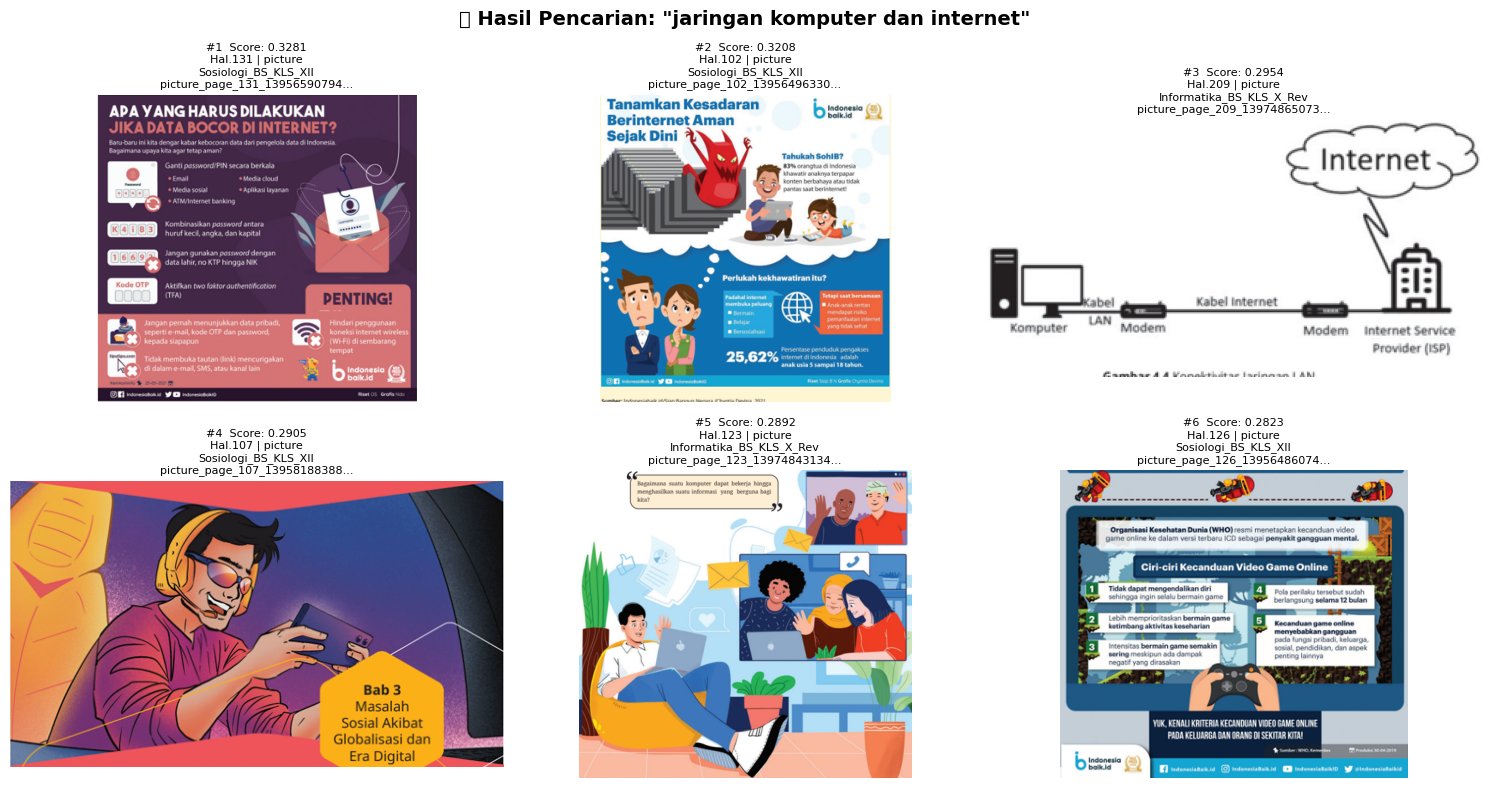

In [18]:
# ── Cari semua aset dari semua sumber ─────────────────
query   = "jaringan komputer dan internet"
results = search_by_text(query, top_k=6)

print(f"🔍 Query : '{query}'")
print(f"📊 Hasil : {len(results)} gambar\n")
for r in results:
    print(f"  Score: {r.score:.4f} | {r.payload['source']} | Hal.{r.payload['page_num']} | {r.payload['filename']}")

display_results(results, query_label=query)

🔍 Query : 'diagram alur flowchart' | Filter: picture only
  Score: 0.3095 | Dasar-Kimia-Analisis-BS-KLS-X | Hal.150 | picture_page_150_139748656413776.png
  Score: 0.3075 | Dasar-Kimia-Analisis-BS-KLS-X | Hal.86 | picture_page_86_139748780370880.png
  Score: 0.3065 | Fisika-BS-KLS-XI | Hal.112 | picture_page_112_140475606434672.png
  Score: 0.3056 | Informatika_BS_KLS_X_Rev | Hal.73 | picture_page_73_139749337712992.png
  Score: 0.3052 | Informatika_BS_KLS_XI_Rev | Hal.224 | picture_page_224_139752817218480.png
  Score: 0.2997 | Islam_BS_KLS_XII_ | Hal.226 | picture_page_226_139751204249728.png


C:\Users\user\AppData\Local\Temp\ipykernel_25744\2501811917.py:109: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


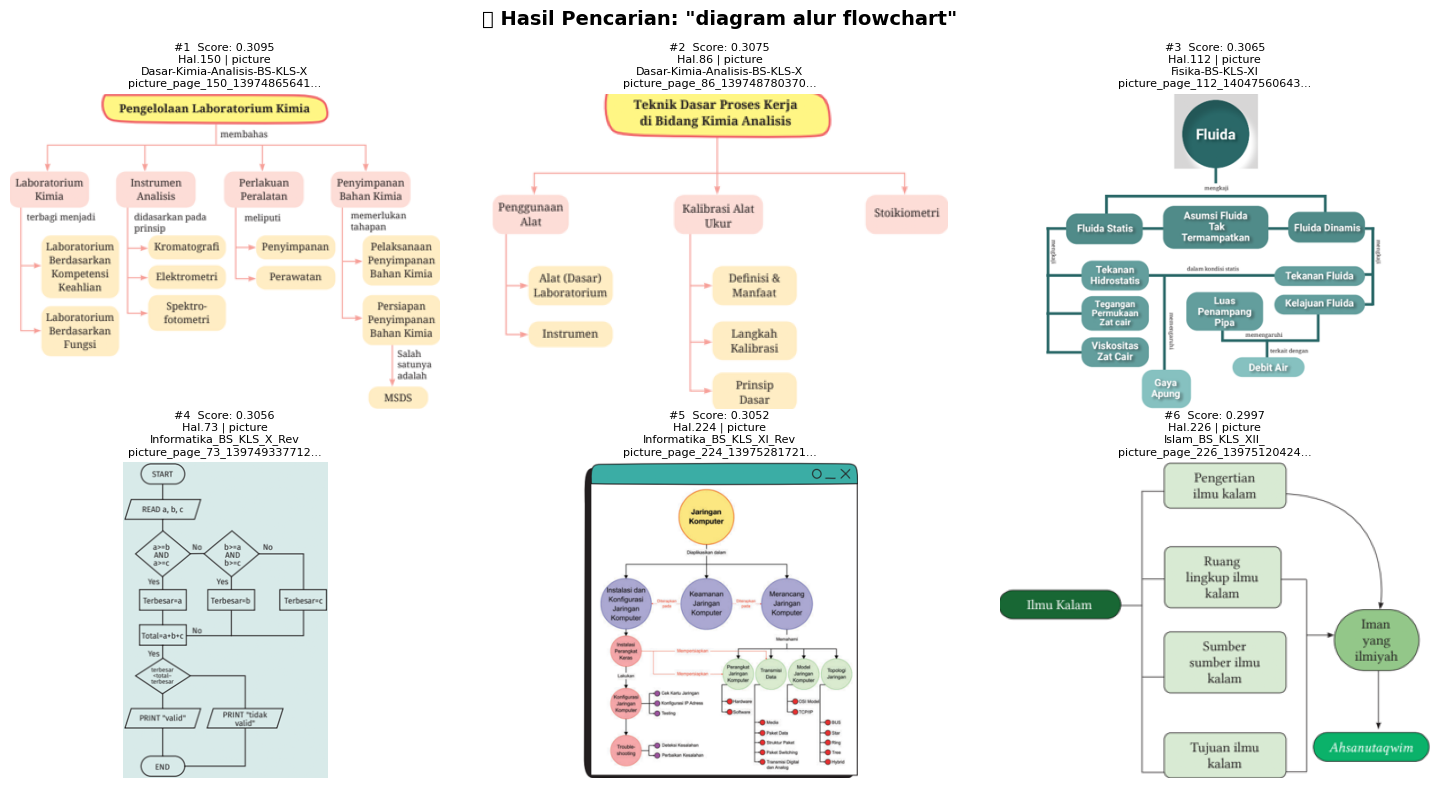

In [19]:
# ── Filter hanya 'picture' ─────────────────────────────
query   = "diagram alur flowchart"
results = search_by_text(query, top_k=6, asset_type="picture")

print(f"🔍 Query : '{query}' | Filter: picture only")
for r in results:
    print(f"  Score: {r.score:.4f} | {r.payload['source']} | Hal.{r.payload['page_num']} | {r.payload['filename']}")

display_results(results, query_label=query)

🔍 Query : 'tabel perbandingan data' | Filter: table only
  Score: 0.3197 | Informatika_BS_KLS_XII | Hal.212 | table_page_212_139751730031152.png
  Score: 0.3025 | Informatika_BS_KLS_XII | Hal.119 | table_page_119_139753874059936.png
  Score: 0.3022 | Informatika_BS_KLS_X_Rev | Hal.18 | table_page_18_139753887707808.png
  Score: 0.3018 | Informatika_BS_KLS_XII | Hal.214 | table_page_214_139753903358592.png
  Score: 0.3003 | buku-panduan-guru-antropologi-untuk-smama-kelas-xii | Hal.59 | table_page_59_140474815416112.png
  Score: 0.3001 | IPA_BS_KLS_X_Rev | Hal.23 | table_page_23_139748671800416.png


C:\Users\user\AppData\Local\Temp\ipykernel_25744\2501811917.py:109: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


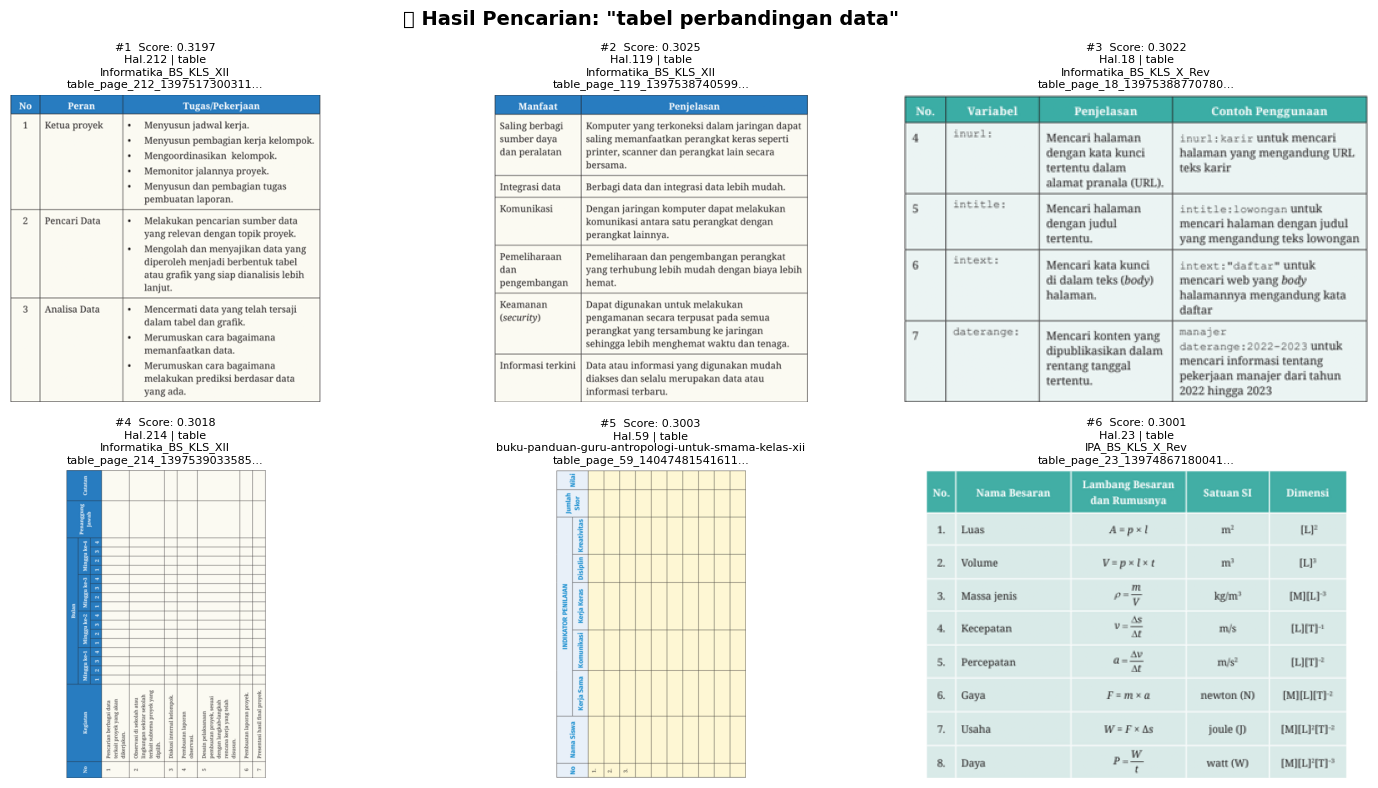

In [20]:
# ── Filter hanya 'table' ───────────────────────────────
query   = "tabel perbandingan data"
results = search_by_text(query, top_k=6, asset_type="table")

print(f"🔍 Query : '{query}' | Filter: table only")
for r in results:
    print(f"  Score: {r.score:.4f} | {r.payload['source']} | Hal.{r.payload['page_num']} | {r.payload['filename']}")

display_results(results, query_label=query)

🔍 Query : 'algoritma pemrograman' | Filter: Informatika KLS X
  Score: 0.2934 | Informatika_BS_KLS_X_Rev | Hal.53 | table_page_53_139748659679376.png
  Score: 0.2924 | Informatika_BS_KLS_X_Rev | Hal.40 | picture_page_40_139752954620944.png
  Score: 0.2913 | Informatika_BS_KLS_X_Rev | Hal.53 | table_page_53_139748659680336.png
  Score: 0.2891 | Informatika_BS_KLS_X_Rev | Hal.52 | table_page_52_139748659677216.png
  Score: 0.2857 | Informatika_BS_KLS_X_Rev | Hal.52 | table_page_52_139748659676256.png
  Score: 0.2623 | Informatika_BS_KLS_X_Rev | Hal.217 | picture_page_217_139750553657232.png


C:\Users\user\AppData\Local\Temp\ipykernel_25744\2501811917.py:109: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


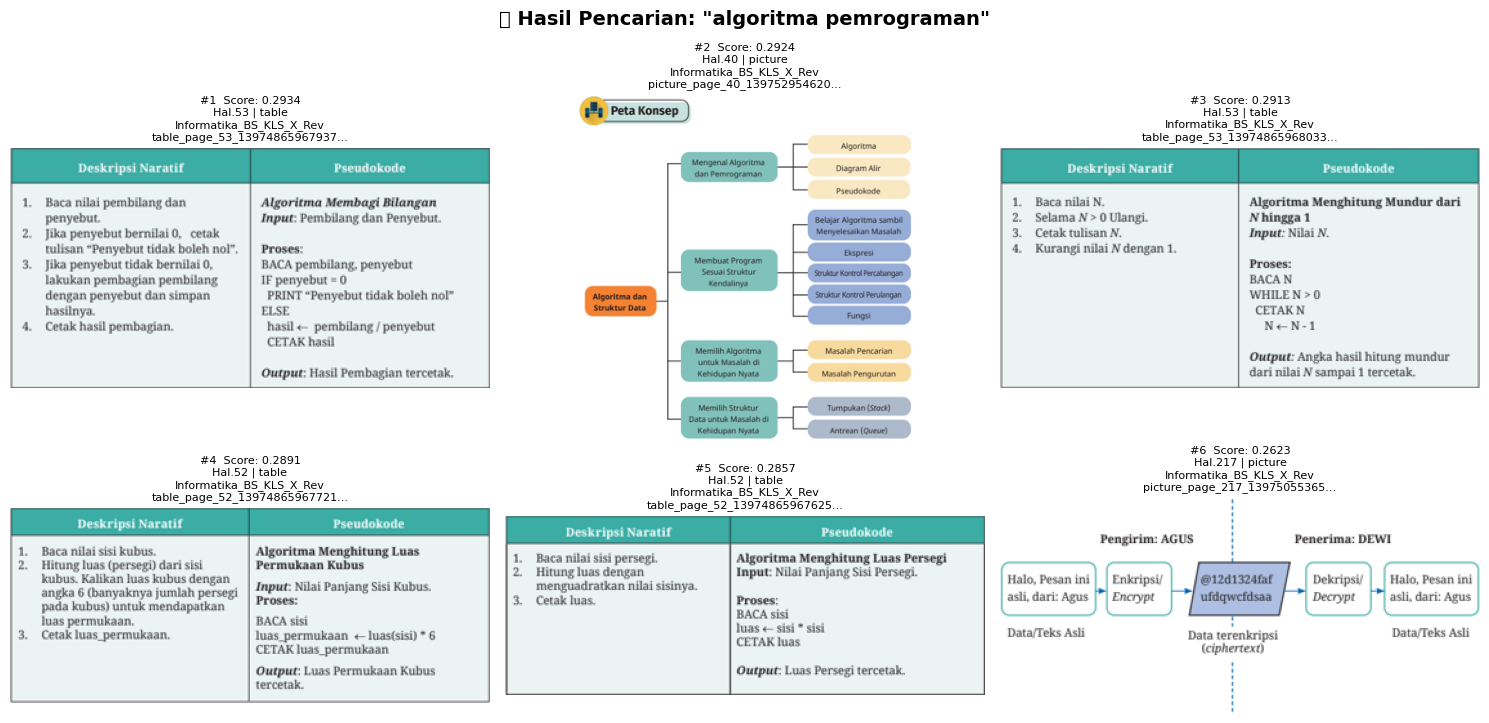

In [21]:
# ── Filter berdasarkan sumber buku tertentu ────────────
query   = "algoritma pemrograman"
results = search_by_text(query, top_k=6, source="Informatika_BS_KLS_X_Rev")

print(f"🔍 Query : '{query}' | Filter: Informatika KLS X")
for r in results:
    print(f"  Score: {r.score:.4f} | {r.payload['source']} | Hal.{r.payload['page_num']} | {r.payload['filename']}")

display_results(results, query_label=query)

## 9. 🖼️ Image-to-Image Search

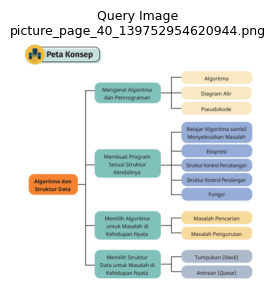


📊 Top 6 gambar paling mirip:
  Score: 0.8316 | Informatika_BS_KLS_X_Rev | picture_page_14_139752679241632.png
  Score: 0.8295 | Informatika_BS_KLS_XII | picture_page_52_139751074245168.png
  Score: 0.7927 | Matematika_BS_KLS_XI_TL_Rev | picture_page_62_140518952843168.png
  Score: 0.7865 | Informatika_BS_KLS_X_Rev | picture_page_200_139748151742208.png
  Score: 0.7806 | Informatika_BS_KLS_XI_Rev | picture_page_150_139753614634240.png
  Score: 0.7710 | Fisika-BS-KLS-XI | picture_page_24_140475628163136.png


C:\Users\user\AppData\Local\Temp\ipykernel_25744\2501811917.py:109: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


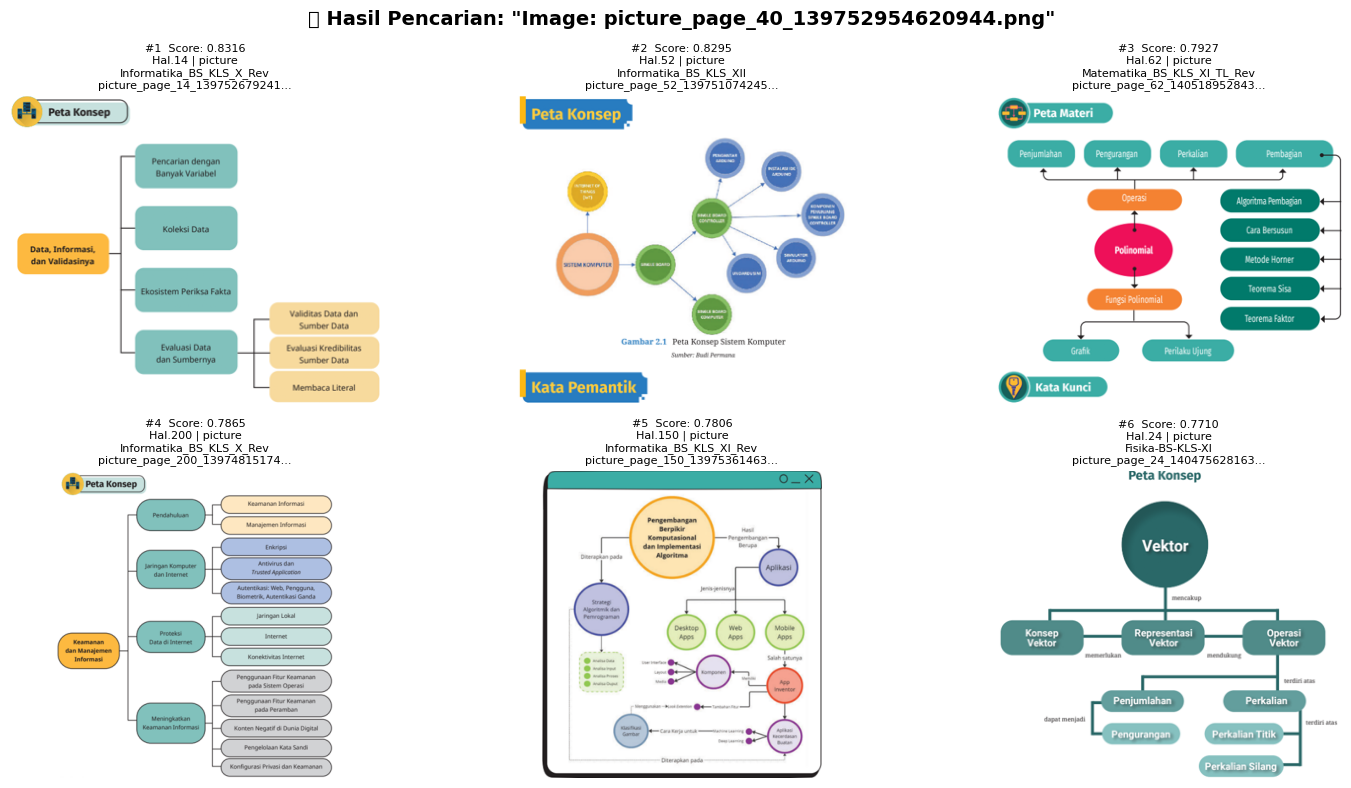

In [22]:
# ── Ganti path ke gambar query yang diinginkan ─────────
query_image_path = Path(r"extraction/output_multimodal_Informatika_BS_KLS_X_Rev/extracted_assets/picture_page_40_139752954620944.png")

assert query_image_path.exists(), f"❌ File tidak ditemukan: {query_image_path}"

# Tampilkan gambar query
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.imshow(mpimg.imread(str(query_image_path)))
ax.set_title(f"Query Image\n{query_image_path.name}", fontsize=9)
ax.axis("off")
plt.tight_layout()
plt.show()

# Cari gambar serupa
results = search_by_image(query_image_path, top_k=7)

# Hapus hasil teratas jika identik dengan query (score ~1.0)
if results and results[0].payload["filename"] == query_image_path.name:
    results = results[1:]
else:
    results = results[:6]

print(f"\n📊 Top {len(results)} gambar paling mirip:")
for r in results:
    print(f"  Score: {r.score:.4f} | {r.payload['source']} | {r.payload['filename']}")

display_results(results, query_label=f"Image: {query_image_path.name}")

## 10. All-in-One Search Function

🔍 CLIP Image Search
   Mode       : text
   Query      : jaringan komputer
   Top-K      : 6
   Aset       : Semua
   Sumber     : Semua

📊 6 hasil ditemukan:
  Score: 0.2916 | Fisika-BS-KLS-XI | Hal.191 | picture_page_191_140473162319184.png
  Score: 0.2698 | Dasar-Kimia-Analisis-BS-KLS-X | Hal.158 | picture_page_158_139753480972928.png
  Score: 0.2691 | IPS_BS_KLS_X_Rev | Hal.30 | picture_page_30_139749052298448.png
  Score: 0.2674 | IPS_BS_KLS_X_Rev | Hal.233 | picture_page_233_139751090791888.png
  Score: 0.2638 | Bahasa_Indonesia_BS_KLS_X_Rev | Hal.89 | picture_page_89_139748970093040.png
  Score: 0.2628 | cerdas-cergas-berbahasa-dan-bersastra-indonesia-untuk-smasmkma-kelas-xii | Hal.187 | picture_page_187_140459008615408.png


C:\Users\user\AppData\Local\Temp\ipykernel_25744\2501811917.py:109: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


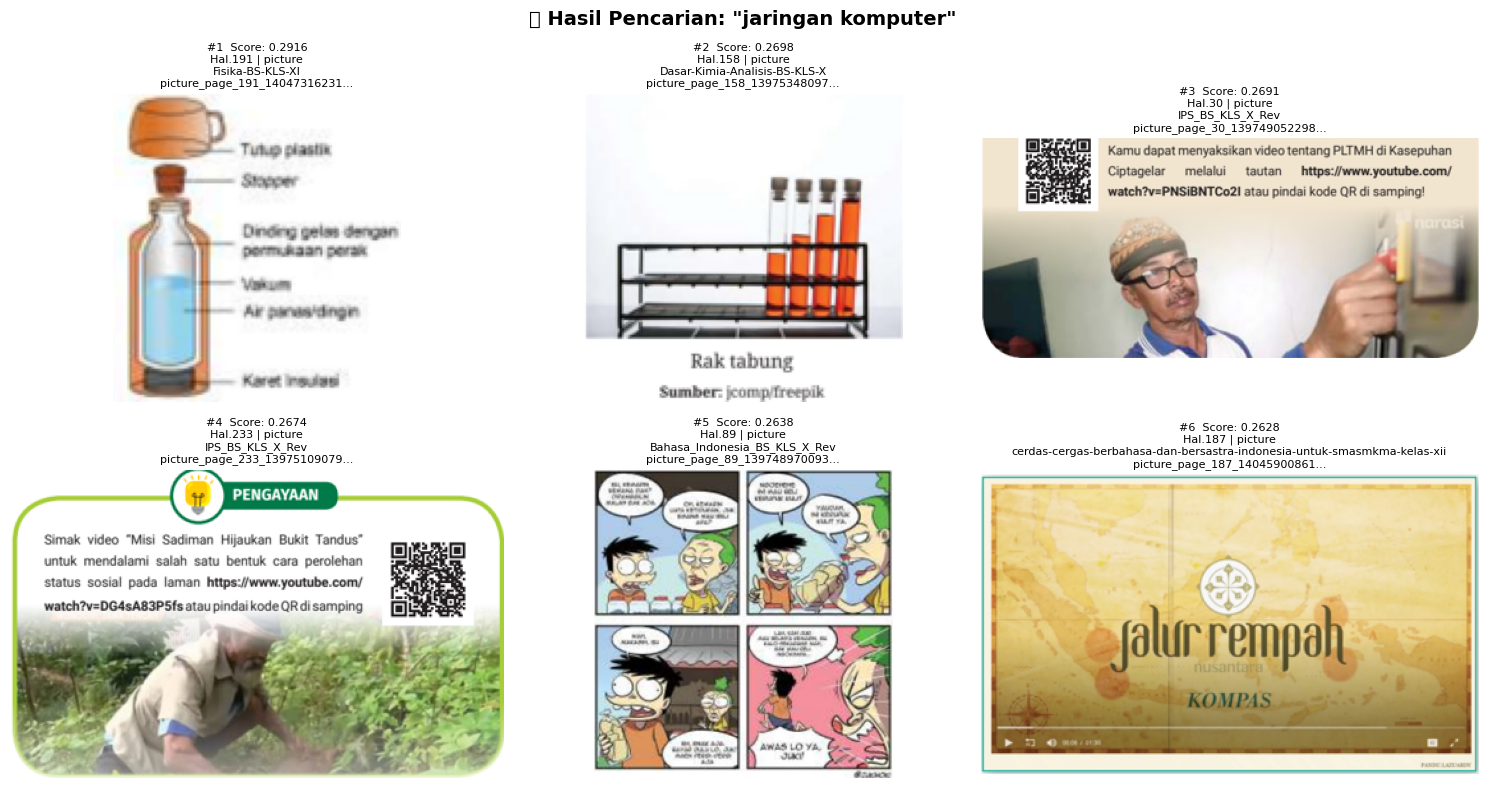

[ScoredPoint(id=1123, version=71, score=0.29162878, payload={'filename': 'picture_page_191_140473162319184.png', 'filepath': 'extraction\\output_multimodal_Fisika-BS-KLS-XI\\extracted_assets\\picture_page_191_140473162319184.png', 'asset_type': 'picture', 'page_num': 191, 'source': 'Fisika-BS-KLS-XI'}, vector=None, shard_key=None),
 ScoredPoint(id=989, version=62, score=0.26977947, payload={'filename': 'picture_page_158_139753480972928.png', 'filepath': 'extraction\\output_multimodal_Dasar-Kimia-Analisis-BS-KLS-X\\extracted_assets\\picture_page_158_139753480972928.png', 'asset_type': 'picture', 'page_num': 158, 'source': 'Dasar-Kimia-Analisis-BS-KLS-X'}, vector=None, shard_key=None),
 ScoredPoint(id=2253, version=141, score=0.2690956, payload={'filename': 'picture_page_30_139749052298448.png', 'filepath': 'extraction\\output_multimodal_IPS_BS_KLS_X_Rev\\extracted_assets\\picture_page_30_139749052298448.png', 'asset_type': 'picture', 'page_num': 30, 'source': 'IPS_BS_KLS_X_Rev'}, vector

In [23]:
def clip_search(
    query: str,
    top_k: int = 5,
    asset_type: str = None,
    source: str = None,
    mode: str = "text"
) -> list:
    """
    All-in-one CLIP Image Search.

    Args:
        query      : Teks query ATAU path ke file gambar
        top_k      : Jumlah hasil
        asset_type : 'picture', 'table', atau None (semua)
        source     : Nama sumber buku (tanpa prefix 'output_multimodal_'), atau None (semua)
        mode       : 'text' atau 'image'
    """
    print(f"{'='*55}")
    print(f"🔍 CLIP Image Search")
    print(f"   Mode       : {mode}")
    print(f"   Query      : {query}")
    print(f"   Top-K      : {top_k}")
    print(f"   Aset       : {asset_type or 'Semua'}")
    print(f"   Sumber     : {source or 'Semua'}")
    print(f"{'='*55}")

    if mode == "text":
        results = search_by_text(query, top_k=top_k, asset_type=asset_type, source=source)
    elif mode == "image":
        results = search_by_image(query, top_k=top_k, asset_type=asset_type, source=source)
    else:
        raise ValueError("mode harus 'text' atau 'image'")

    print(f"\n📊 {len(results)} hasil ditemukan:")
    for r in results:
        print(f"  Score: {r.score:.4f} | {r.payload['source']} | Hal.{r.payload['page_num']} | {r.payload['filename']}")

    display_results(results, query_label=str(query))
    return results


# ── Contoh penggunaan ──────────────────────────────────
clip_search(
    query      = "jaringan komputer",
    top_k      = 6,
    asset_type = None,
    source     = None,
    mode       = "text"
)